In [1]:
%load_ext autoreload
%autoreload 2

import rootutils
rootutils.setup_root('.', dotenv=True, pythonpath=True, cwd=True)

PosixPath('/home/milton/workspace/ocdm')

In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from itertools import product
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from torchvision.utils import make_grid

from src.model.vae import BetaVAE, WassersteinMMDAE
from src.model.slot import SlotAutoencoder, FigureGroundAutoencoder
from src.dataset.dsprites import DSprites
from src.dataset.shapes3d import Shapes3D
from src.dataset.pentominos import Pentominos
from src.dataset.utils import build_filter
from src.analysis.viz import strip

torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [6]:
def log_reconstructions_from_loader(model, dataset, num_samples=10):
    x = [dataset[i][0] for i in np.random.choice(len(dataset), size=num_samples)]
    x = torch.stack(x).to(model.device)

    with torch.no_grad():
        assert hasattr(model, 'reconstruction')
        x_hat = model.reconstruction(x)  # type: ignore

    n = min(num_samples, len(x))
    comparison = torch.cat([x[:n], x_hat[:n]]).cpu()
    grid = make_grid(comparison, nrow=n, normalize=False).clip(0, 1)
    return grid

# Comparing WAE to SlotAttention

In [4]:
_filter = build_filter(Pentominos, "( shape == 6 ) & ( angle >= 180) & ( pos_y > 0.52 ) & ( pos_y < 0.53 ) & ( pos_x > 0.52 ) & ( pos_x < 0.53 ) & ( scale == 2.25 )")
pentominos_plot = Pentominos("data/datasets/pentominos", data_filter=_filter)
# Pentominos.unique_values

In [5]:
vae_runs = [
    "data/logs/figure2/combgen_pentominos_rotation/vae/2026-03-31_19-34/epoch=37-step=485000.ckpt"
]

wae_runs = [
    "data/logs/figure2/combgen_pentominos_rotation/wae/2026-03-31_12-09/epoch=36-step=470000.ckpt"
]

sa_runs = [
    # "data/logs/figure2/combgen_pentominos_rotation/sa/2026-04-01_03-46/epoch=38-step=500000.ckpt",
    # "data/logs/figure2/combgen_pentominos_rotation/sa/2026-04-01_13-10/epoch=38-step=495000.ckpt",
    # "data/logs/figure2/combgen_pentominos_rotation/sa/2026-04-03_15-19/epoch=29-step=385000.ckpt",
    "data/logs/figure2/combgen_pentominos_rotation/sa/2026-04-03_16-12/epoch=38-step=500000.ckpt",
]

sa1 = FigureGroundAutoencoder.load_from_checkpoint(sa_runs[0]).cpu()
vae = BetaVAE.load_from_checkpoint(vae_runs[0]).cpu()
wae = WassersteinMMDAE.load_from_checkpoint(wae_runs[0]).cpu()

In [6]:
sa1_pentominos = log_reconstructions_from_loader(sa1, pentominos_plot)
wae_pentominos = log_reconstructions_from_loader(wae, pentominos_plot)

In [7]:
_filter = build_filter(DSprites, "( posY > 0.51 ) & ( posY < 0.52 ) & ( scale == 0.6 )")
dsprite_plot = DSprites("data/datasets/dsprites/dsprites_train.hdf5", data_filter=_filter)

In [8]:
sa1_dsprites = log_reconstructions_from_loader(sa1, dsprite_plot)
wae_dsprites = log_reconstructions_from_loader(wae, dsprite_plot)

In [9]:
_filter = build_filter(Pentominos, "( pos_y > 0.52 ) & ( pos_y < 0.53 ) & ( pos_x > 0.52 ) & ( pos_x < 0.53 ) & ( scale == 1.5 )")
non_pentominos_plot = Pentominos("data/datasets/non_pentominos", data_filter=_filter)
# Pentominos.unique_values

In [10]:
sa1_non_petominos = log_reconstructions_from_loader(sa1, non_pentominos_plot)
wae_non_petominos = log_reconstructions_from_loader(wae, non_pentominos_plot)

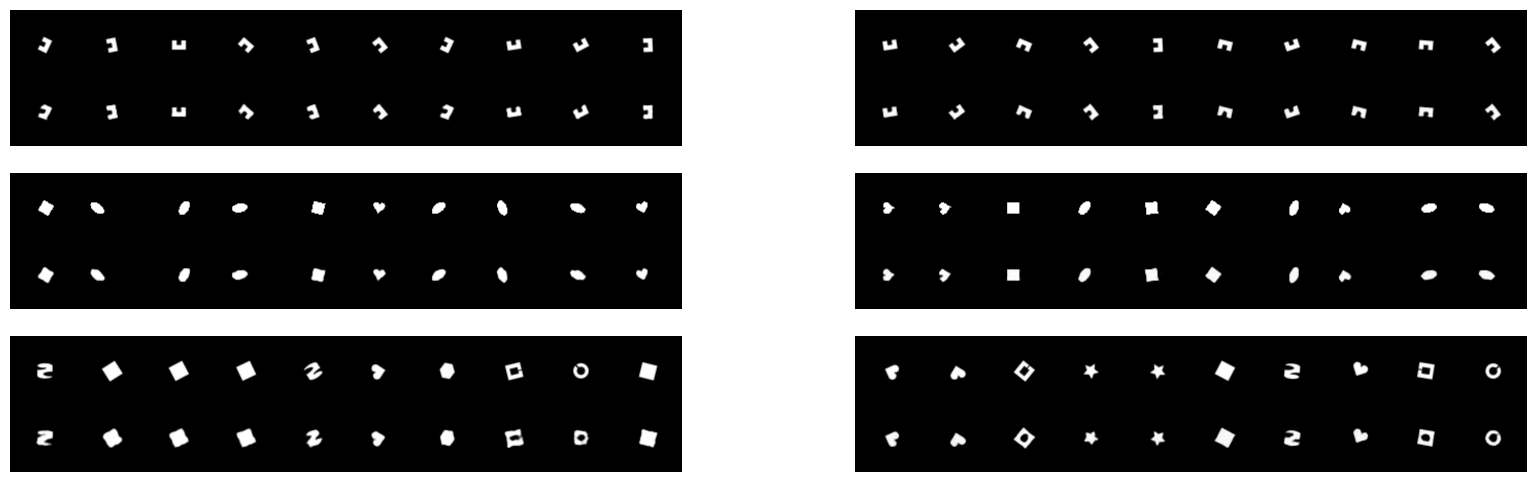

In [11]:
fig, axes = plt.subplots(ncols=2, nrows=3, figsize=(20, 6))

for ax in axes.reshape(-1):
    ax.axis('off')

axes[0,0].imshow(sa1_pentominos.cpu().numpy().transpose(1, 2, 0))
axes[0,1].imshow(wae_pentominos.cpu().numpy().transpose(1, 2, 0))

axes[1,0].imshow(sa1_dsprites.cpu().numpy().transpose(1, 2, 0))
axes[1,1].imshow(wae_dsprites.cpu().numpy().transpose(1, 2, 0));

axes[2,0].imshow(sa1_non_petominos.cpu().numpy().transpose(1, 2, 0))
axes[2,1].imshow(wae_non_petominos.cpu().numpy().transpose(1, 2, 0));

## Inspecting SA(1)

### Pentominos

In [28]:
x = [pentominos_plot[i][0] for i in np.random.choice(len(pentominos_plot), size=20)]
x = torch.stack(x).to(sa1.device)
recons, slots, decoder_masks = sa1(x)

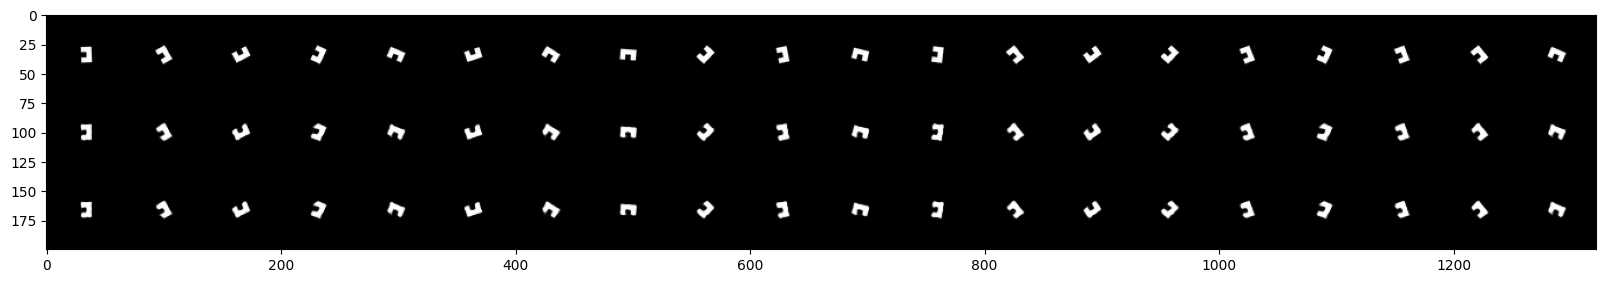

In [31]:
imgs = torch.cat([x, recons, decoder_masks])
grid = make_grid(imgs, nrow=len(x))
plt.figure(figsize=(20, 5))
plt.imshow(grid.cpu().numpy().transpose(1, 2, 0).clip(0, 1));

### dSprites

In [32]:
x = [dsprite_plot[i][0] for i in np.random.choice(len(dsprite_plot), size=20)]
x = torch.stack(x).to(sa1.device)
recons, slots, decoder_masks = sa1(x)

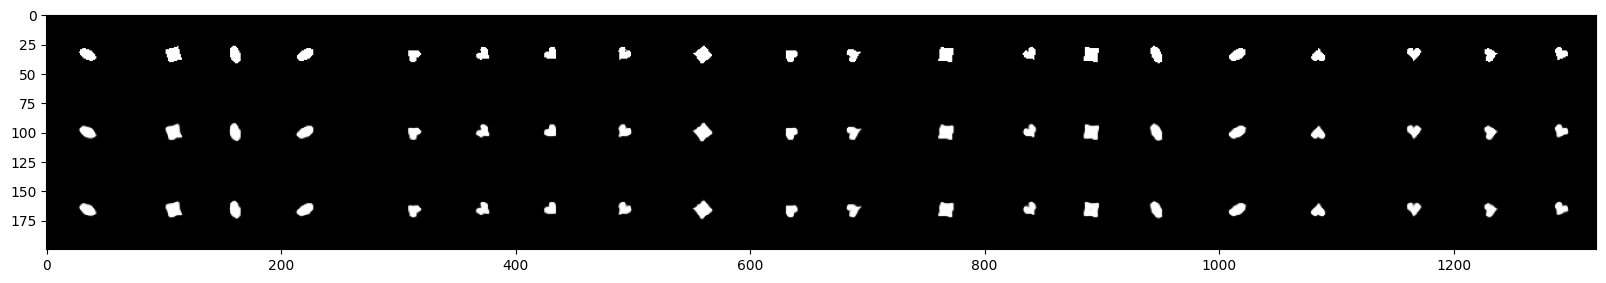

In [33]:
imgs = torch.cat([x, recons, decoder_masks])
grid = make_grid(imgs, nrow=len(x))
plt.figure(figsize=(20, 5))
plt.imshow(grid.cpu().numpy().transpose(1, 2, 0).clip(0, 1));

### Non-Pentominos

In [34]:
x = [non_pentominos_plot[i][0] for i in np.random.choice(len(non_pentominos_plot), size=20)]
x = torch.stack(x).to(sa1.device)
recons, slots, decoder_masks = sa1(x)

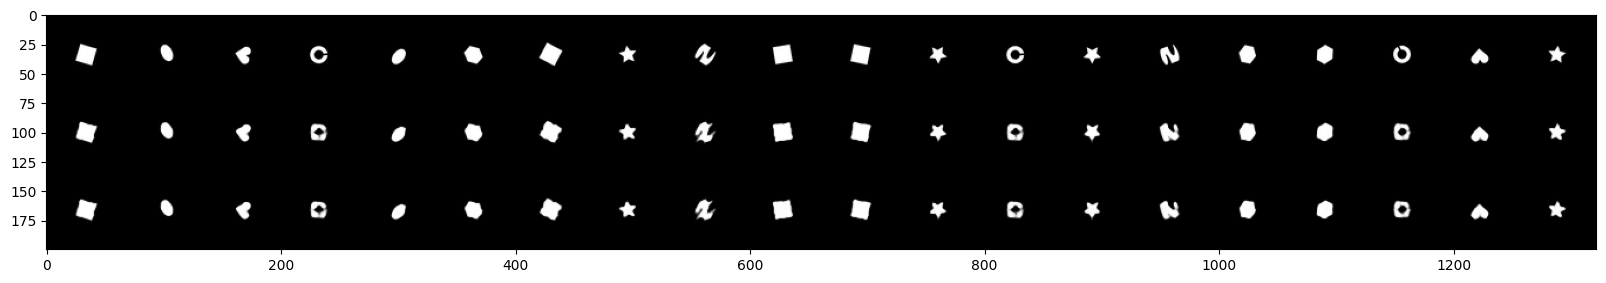

In [35]:
imgs = torch.cat([x, recons, decoder_masks])
grid = make_grid(imgs, nrow=len(x))
plt.figure(figsize=(20, 5))
plt.imshow(grid.cpu().numpy().transpose(1, 2, 0).clip(0, 1));

# SLATE experiments to scale up findings

In [3]:
from src.model.slate import SLATE
from src.model.vtae import VTAE

# slate = SLATE.load_from_checkpoint("data/logs/baseline_shapes3d/slate/2026-04-05_12-37/epoch=33-step=100000.ckpt").eval()
# slate = SLATE.load_from_checkpoint("data/logs/combgen_shapes3d/slate/2026-04-05_12-52/epoch=32-step=100000.ckpt").eval()
# slate = SLATE.load_from_checkpoint("data/logs/baseline_shapes3d/slate/2026-04-05_17-21/epoch=33-step=100000.ckpt").eval()
# slate = SLATE.load_from_checkpoint("data/logs/combgen_shapes3d_shape_hue/slate/2026-04-05_16-26/epoch=32-step=100000.ckpt").eval()
slate = SLATE.load_from_checkpoint("data/logs/combgen_shapes3d_shape_hue/slate/2026-04-05_20-40/epoch=131-step=400000.ckpt").eval()

# vtae = VTAE.load_from_checkpoint("data/logs/j

In [4]:
_filter = build_filter(
    Shapes3D,
    "( shape == 3 ) & ( wall_hue == 0.8) * ( orientation == 0 ) & ( scale > 1.24 ) & ( scale < 1.26 )"
)

shapes3d_plot = Shapes3D("data/datasets/shapes3d//3dshapes.h5", data_filter=_filter)

In [48]:
x = [shapes3d_plot[i][0] for i in np.random.choice(len(shapes3d_plot), size=20)]
x = torch.stack(x).to(slate.device)

In [102]:
recons, (slots, attn), _ = slate(x)
print(recons.shape, attn.shape, slots.shape)

torch.Size([20, 3, 64, 64]) torch.Size([20, 256, 4]) torch.Size([20, 4, 64])


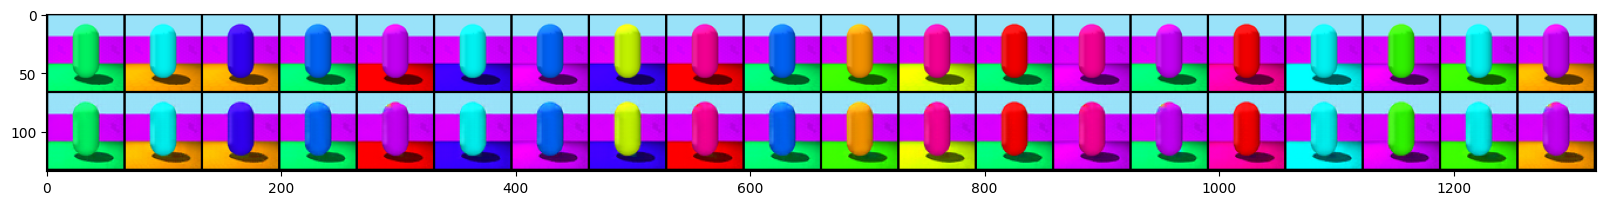

In [50]:
imgs = torch.cat([x, recons])
grid = make_grid(imgs, nrow=len(x))
plt.figure(figsize=(20, 5))
plt.imshow(grid.cpu().numpy().transpose(1, 2, 0).clip(0, 1));